# SR4 · Regime Detection: Calm Markets and Turbulent Markets

Markets seem to switch between moods: long calm stretches, then turbulent ones. A regime-switching model makes that idea precise. It estimates which "mood" the market is probably in today, using only data up to today.

## 1. Motivation

Many strategies work well in one environment and badly in another. Trend-following struggles in choppy markets. Selling options works until volatility explodes. Even a plain stock portfolio behaves very differently in 2017 than in March 2020. If we could tell, in real time, which kind of market we are in, we could switch strategies or scale risk accordingly. The hard part is "in real time": in hindsight, regimes are obvious.

## 2. Intuition

Imagine a casino that secretly switches between a fair die and a loaded one. You only see the rolls, never which die is in use. After a run of sixes, you would start to suspect the loaded die. You can't be sure, but you can put a **probability** on it. And because the casino switches rarely, a die that was loaded yesterday is probably still loaded today.

A **hidden Markov model** (HMM) applies this to markets:
- The hidden state is the regime, e.g. "calm" or "turbulent".
- Each regime produces returns with its own mean and volatility.
- Regimes are *persistent*: today's regime is probably the same as yesterday's.

The model learns the two return distributions and how often the regimes switch. Then, day by day, it updates the probability of being in each regime. This is the same "predict, then update" logic as the Kalman filter in SR3, but with a discrete state.

## 3. The math

Let $S_t \in \{1, 2\}$ be the hidden regime. Returns depend on it:
$$
R_t \mid S_t = k \;\sim\; \mathcal N(\mu_k, \sigma_k^2).
$$
The regime follows a **Markov chain** with transition probabilities $p_{jk} = \Pr(S_t = k \mid S_{t-1} = j)$. A large $p_{kk}$ means regime $k$ is sticky. Its expected duration is $1/(1-p_{kk})$ days.

**Filtering** (the probabilities we could have known at the time). Let $\xi_{t-1}(j) = \Pr(S_{t-1} = j \mid R_1,\dots,R_{t-1})$. Each day:

1. **Predict:** $\Pr(S_t = k \mid \text{data to } t-1) = \sum_j p_{jk}\,\xi_{t-1}(j)$.
2. **Update** with today's return, using Bayes' rule:
$$
\xi_t(k) = \frac{\phi(R_t;\,\mu_k,\sigma_k)\;\Pr(S_t = k \mid \text{data to } t-1)}{\sum_{m}\phi(R_t;\,\mu_m,\sigma_m)\;\Pr(S_t = m \mid \text{data to } t-1)},
$$
where $\phi$ is the normal density. A return that is very unlikely under the calm regime shifts probability towards the turbulent one.

**Smoothing vs. filtering.** Software also reports **smoothed** probabilities, which use the *whole* sample, including the future. They give nicer charts, but using them in a backtest is look-ahead bias. Only filtered probabilities are allowed in a strategy.

The parameters $(\mu_k, \sigma_k, p_{jk})$ are estimated by maximum likelihood. To keep the test honest, we estimate them on 2010–2017 only, and then run the filter on 2018–2026 with those parameters fixed.

## 4. Code it

### 4.1 Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

warnings.filterwarnings("ignore")   # the optimiser prints convergence chatter; results are checked below
pd.set_option("display.width", 120)

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

spy = prices["SPY"].pct_change().dropna() * 100      # daily returns in percent (helps the optimiser)
rf = (prices["^IRX"].ffill() / 100 / 252).shift(1).reindex(spy.index).fillna(0)

### 4.2 Fit a two-regime model on 2010–2017

In [2]:
train = spy[:"2017"]
model_train = MarkovRegression(train, k_regimes=2, trend="c", switching_variance=True)
fit = model_train.fit(search_reps=20)        # several random starting points, keep the best

params = fit.params
# Label the regimes so that regime 0 is always the calm (low-variance) one
var = np.array([params["sigma2[0]"], params["sigma2[1]"]])
calm = int(np.argmin(var))
turb = 1 - calm
p_stay = [fit.regime_transition[k, k, 0] for k in (0, 1)]    # p_kk

summary = pd.DataFrame({
    "Daily mean (%)": [params[f"const[{calm}]"], params[f"const[{turb}]"]],
    "Annual vol (%)": np.sqrt(var[[calm, turb]] * 252),
    "Stay probability p_kk": [p_stay[calm], p_stay[turb]],
    "Expected duration (days)": [1 / (1 - p_stay[calm]), 1 / (1 - p_stay[turb])],
}, index=["Calm", "Turbulent"])
summary.round(3)

,Daily mean (%),Annual vol (%),Stay probability p_kk,Expected duration (days)
Calm,0.111,8.048,0.967,30.670
Turbulent,-0.040,21.542,0.944,17.768


The model finds two clearly different regimes in 2010–2017:

- **Calm:** about 8% annual volatility and a positive average return (about 0.11% a day). It lasts about a month on average.
- **Turbulent:** about 21% volatility and a slightly *negative* average return. It lasts a few weeks.

Both regimes are sticky ($p_{kk}$ above 0.94), which matches what notebook 2 showed: volatility comes in clusters. Note that the main difference between the regimes is volatility, not mean return. Daily means are estimated very imprecisely (PR1), so the model relies mostly on the size of the moves.

### 4.3 Filter the full sample with the fixed parameters

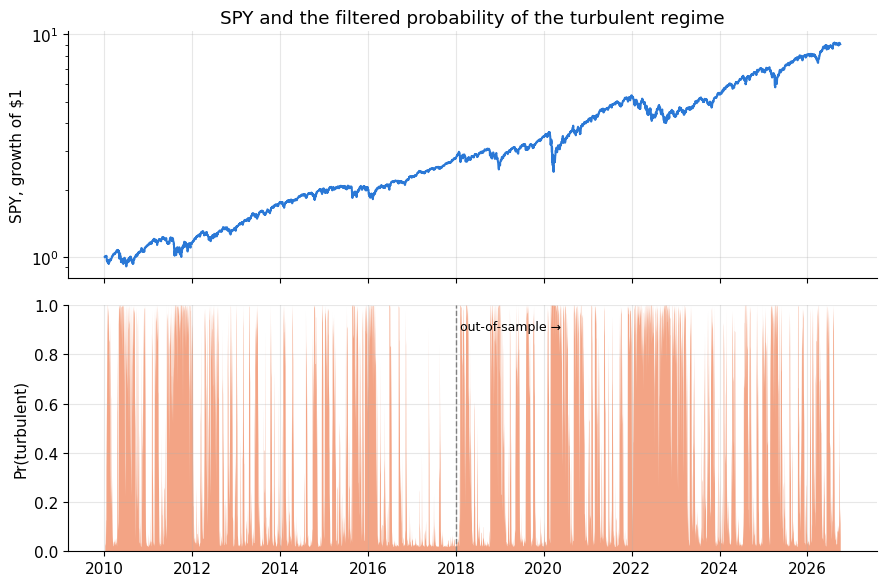

Share of days classified turbulent (prob > 0.5): 41%


In [3]:
# Build the model on all data, but evaluate it with the parameters learned on 2010-2017 only
model_all = MarkovRegression(spy, k_regimes=2, trend="c", switching_variance=True)
res_all = model_all.filter(params)
p_turb = res_all.filtered_marginal_probabilities[turb]      # Pr(turbulent | data up to t)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot((1 + spy / 100).cumprod(), color=COLORS[0])
axes[0].set_yscale("log")
axes[0].set_ylabel("SPY, growth of $1")
axes[0].set_title("SPY and the filtered probability of the turbulent regime")
axes[1].fill_between(p_turb.index, p_turb, color=COLORS[1], alpha=0.6, linewidth=0)
axes[1].axvline(pd.Timestamp("2018-01-01"), color="grey", ls="--", linewidth=1)
axes[1].text(pd.Timestamp("2018-02-01"), 0.9, "out-of-sample →", fontsize=9)
axes[1].set_ylabel("Pr(turbulent)")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Share of days classified turbulent (prob > 0.5): {(p_turb > 0.5).mean():.0%}")

The turbulent probability lights up in the periods you would expect: the 2011 euro crisis, early 2016, 2018, the 2020 crash, most of 2022, and the 2025 sell-off. It does so out-of-sample too, with parameters estimated before any of those later events. It is also *jumpy*: filtered probabilities react to every big day, so they flip back and forth more than the smooth regimes you see in textbooks (those charts usually show smoothed probabilities, see Section 4.5).

### 4.4 Using the regime: scale down when turbulent

A simple rule: hold SPY in proportion to the probability of the calm regime, $w_t = 1 - \Pr(\text{turbulent} \mid \text{data to } t)$, decided at the close and held the next day. We compare it with buy-and-hold and with the volatility-targeting rule from PR5, on the **out-of-sample** period only.

In [4]:
r = spy / 100
w_regime = (1 - p_turb).shift(1)                                       # decided yesterday
sigma_hat = r.rolling(63).std() * np.sqrt(252)
w_vt = (0.12 / sigma_hat).clip(upper=1.0).shift(1)                     # vol target (PR5), no leverage

strats = pd.DataFrame({
    "Buy & hold": r,
    "Regime-scaled": w_regime * r + (1 - w_regime) * rf,
    "Vol-targeted": w_vt * r + (1 - w_vt) * rf,
})["2018":].dropna()

value = (1 + strats).cumprod()
ex = strats.sub(rf.reindex(strats.index), axis=0)
perf = pd.DataFrame({
    "CAGR": value.iloc[-1] ** (252 / len(strats)) - 1,
    "Volatility": strats.std() * np.sqrt(252),
    "Sharpe": np.sqrt(252) * ex.mean() / ex.std(),
    "Max drawdown": (value / value.cummax() - 1).min(),
    "Avg weight": [1.0, w_regime["2018":].mean(), w_vt["2018":].mean()],
})
fmt = {"CAGR": "{:.1%}", "Volatility": "{:.1%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.1%}", "Avg weight": "{:.2f}"}
perf.apply(lambda col: col.map(fmt[col.name].format))

,CAGR,Volatility,Sharpe,Max drawdown,Avg weight
Buy & hold,14.5%,19.0%,0.67,-33.7%,1.00
Regime-scaled,6.6%,7.6%,0.54,-9.0%,0.53
Vol-targeted,10.2%,12.5%,0.63,-19.4%,0.79


- **The regime rule cut risk dramatically.** Its max drawdown was −9% against −34% for buy-and-hold, and its volatility was 7.6%.
- **But it paid for that in return.** It held only about half a position on average, often staying cautious after the turbulence had passed, and its Sharpe ratio (0.54) was *lower* than buy-and-hold (0.67).
- **Simple volatility targeting landed in between** and kept more of the return.

So the HMM is a good *risk* tool. Here it did not improve return per unit of risk, and it adds complexity compared with a rolling volatility estimate.

### 4.5 The look-ahead trap: smoothed probabilities

In [5]:
smoothed = model_all.smooth(params).smoothed_marginal_probabilities[turb]
w_cheat = (1 - smoothed).shift(1)                                       # still shifted -- but smoothed uses the future
cheat = (w_cheat * r + (1 - w_cheat) * rf)["2018":].dropna()
print(f"Sharpe with filtered probabilities:  {perf.loc['Regime-scaled', 'Sharpe']:.2f}")
print(f"Sharpe with smoothed probabilities:  {np.sqrt(252) * (cheat - rf.reindex(cheat.index)).mean() / cheat.std():.2f}  <- not achievable")

Sharpe with filtered probabilities:  0.54
Sharpe with smoothed probabilities:  2.15  <- not achievable


The same rule with smoothed probabilities shows a Sharpe ratio of about 2.2, four times the honest result, even though the positions were still shifted by one day. Smoothed probabilities at date $t$ are computed using returns *after* $t$, so they already "know" whether a crash is coming. Whenever you see a regime model with spectacular backtest results, check which probabilities it used.

## 5. Takeaways and where it breaks

- **HMMs turn "the market feels nervous" into a probability**, updated each day with Bayes' rule.
- **In practice, a two-regime model on returns mostly detects volatility regimes.** That is useful, but a simple rolling volatility estimate captures much of the same information.
- **Only filtered probabilities are tradable.** Smoothed probabilities, and parameters fitted on the full sample, are look-ahead bias. Many published regime "strategies" fall into this trap.
- **Where it breaks:** the number of regimes is a choice, regimes may not be stable over decades, the normal distribution within each regime is still too thin-tailed, and the filter only reacts *after* turbulent returns arrive. It describes the present; it does not forecast a crash.
- **Extensions:** use more inputs than SPY returns (credit spreads, VIX, the yield curve), or use the regime probability to switch *between strategies* rather than to scale one.

**What you could build:** a "market weather" indicator for the club: a daily regime probability from several inputs, which every team can use to decide when its strategy should run at full size.